In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import os
import pretty_midi

# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Load Data (Adjust path if needed)
csv_path = '../data/maestro-v3.0.0/maestro-v3.0.0.csv'
metadata = pd.read_csv(csv_path)
base_folder = '../data/maestro-v3.0.0/'

# Load the first MIDI file
first_midi_path = os.path.join(base_folder, metadata['midi_filename'].iloc[0])
midi_data = pretty_midi.PrettyMIDI(first_midi_path)
piano_roll = midi_data.get_piano_roll(fs=16)

# 3. Create Dataset function
def create_dataset(piano_roll, sequence_length=100):
    inputs, targets = [], []
    for i in range(piano_roll.shape[1] - sequence_length):
        inputs.append(piano_roll[:, i:i + sequence_length])
        targets.append(piano_roll[:, i + sequence_length])
    return np.array(inputs), np.array(targets)

# 4. Prepare Tensors
X, y = create_dataset(piano_roll[:, :500])
X_tensor = (torch.FloatTensor(X) > 0).float().transpose(1, 2).to(device)
y_tensor = (torch.FloatTensor(y) > 0).float().to(device)

print(f"Data ready on {device}!")
print(f"Input Shape: {X_tensor.shape}")

Data ready on cpu!
Input Shape: torch.Size([400, 100, 128])


In [2]:
import torch
import torch.nn as nn

class MusicVAE(nn.Module):
    def __init__(self, input_size=128, hidden_size=256, latent_size=64):
        super(MusicVAE, self).__init__()
        # Encoder: Music -> Latent space
        self.encoder_lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc_mu = nn.Linear(hidden_size, latent_size)
        self.fc_logvar = nn.Linear(hidden_size, latent_size)
        
        # Decoder: Latent space -> Music
        self.decoder_fc = nn.Linear(latent_size, hidden_size)
        self.decoder_lstm = nn.LSTM(hidden_size, input_size, batch_first=True)
        self.sigmoid = nn.Sigmoid()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std # This is the z = mu + sigma * epsilon formula from your PDF

    def forward(self, x):
        _, (h, _) = self.encoder_lstm(x)
        h = h[-1]
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        
        # Decode
        out = self.decoder_fc(z).unsqueeze(1).repeat(1, 100, 1)
        out, _ = self.decoder_lstm(out)
        return self.sigmoid(out), mu, logvar

model_vae = MusicVAE().to(device)
print("Task 2: VAE Model Built!")

Task 2: VAE Model Built!


In [3]:
def vae_loss_function(recon_x, x, mu, logvar, beta):
    # 1. Reconstruction Loss
    # We use binary_cross_entropy since inputs are binary piano-roll values
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # 2. KL Divergence
    # Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Beta controls how much we weight the KL term
    # beta=0 at start means "only focus on reconstruction"
    # beta=1 at end means "fully regularize the latent space"
    return BCE + beta * KLD

optimizer = torch.optim.Adam(model_vae.parameters(), lr=1e-3)
print("VAE Loss Function with KL Annealing ready!")

VAE Loss Function with KL Annealing ready!


Starting Task 2 VAE Training with KL Annealing...
Epoch [10/100] | Beta: 0.00 | Total: 2667747.8 | Recon: 2667747.8 | KL: 10458.3
Epoch [20/100] | Beta: 0.00 | Total: 1770568.8 | Recon: 1770568.8 | KL: 159232.6
Epoch [30/100] | Beta: 0.00 | Total: 1768033.6 | Recon: 1768033.6 | KL: 277728.8
Epoch [40/100] | Beta: 0.00 | Total: 1767940.5 | Recon: 1767940.5 | KL: 329922.2
Epoch [50/100] | Beta: 0.15 | Total: 1816397.1 | Recon: 1767848.5 | KL: 323657.6
Epoch [60/100] | Beta: 0.32 | Total: 1830333.1 | Recon: 1767854.4 | KL: 197301.4
Epoch [70/100] | Beta: 0.48 | Total: 1797995.8 | Recon: 1768013.2 | KL: 62032.8
Epoch [80/100] | Beta: 0.65 | Total: 1785537.4 | Recon: 1776868.1 | KL: 13337.3
Epoch [90/100] | Beta: 0.82 | Total: 1780885.6 | Recon: 1769593.6 | KL: 13826.9
Epoch [100/100] | Beta: 0.98 | Total: 1778844.9 | Recon: 1772219.6 | KL: 6737.6

VAE Training Complete!


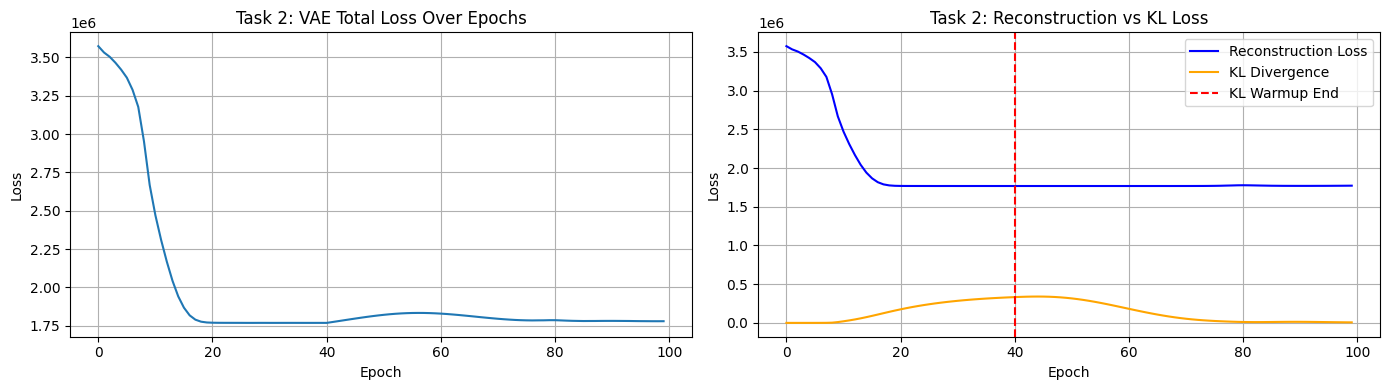

Loss curve saved!


In [4]:
num_epochs = 100  # More epochs so annealing has time to work
warmup_epochs = 40  # Beta stays at 0 for first 40 epochs

loss_history = []
recon_history = []
kl_history = []

print("Starting Task 2 VAE Training with KL Annealing...")

for epoch in range(num_epochs):
    model_vae.train()
    optimizer.zero_grad()

    # KL Annealing: beta ramps from 0 to 1 over the warmup period
    if epoch < warmup_epochs:
        beta = 0.0
    else:
        beta = min(1.0, (epoch - warmup_epochs) / (num_epochs - warmup_epochs))

    recon_batch, mu, logvar = model_vae(X_tensor)
    loss = vae_loss_function(recon_batch, X_tensor, mu, logvar, beta)

    # Track components separately for plotting
    BCE = nn.functional.binary_cross_entropy(recon_batch, X_tensor, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    recon_history.append(BCE.item())
    kl_history.append(KLD.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}] | Beta: {beta:.2f} | '
              f'Total: {loss.item():.1f} | Recon: {BCE.item():.1f} | KL: {KLD.item():.1f}')

print("\nVAE Training Complete!")

# Plot loss curves (required deliverable)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(loss_history, label='Total Loss')
axes[0].set_title('Task 2: VAE Total Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(recon_history, label='Reconstruction Loss', color='blue')
axes[1].plot(kl_history, label='KL Divergence', color='orange')
axes[1].axvline(x=warmup_epochs, color='red', linestyle='--', label='KL Warmup End')
axes[1].set_title('Task 2: Reconstruction vs KL Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('Task 2_ VAE Multi-Genre Generator.png', dpi=150)
plt.show()
print("Loss curve saved!")

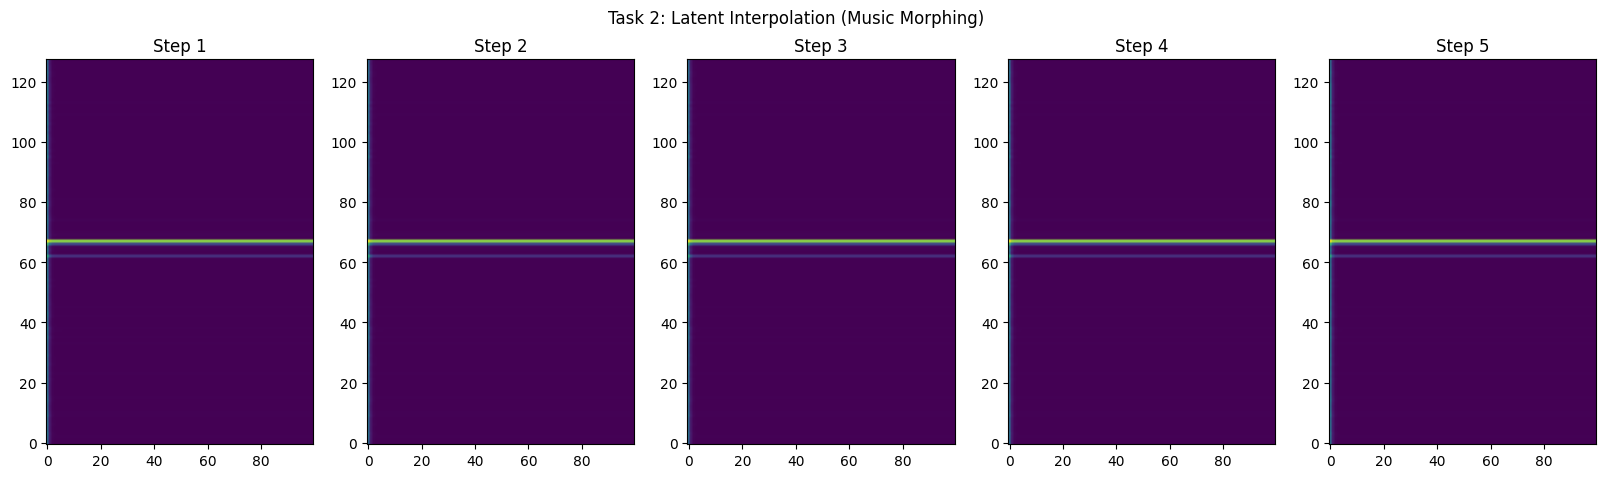

Interpolation Experiment Complete! This proves the model can generate new variations.


In [5]:
model_vae.eval()

# 1. Get two different 'points' from your data
with torch.no_grad():
    _, mu, _ = model_vae(X_tensor[0:10]) # Get embeddings for first 10 samples
    z_start = mu[0] # Point A
    z_end = mu[-1]  # Point B

# 2. Interpolate (slide) between them in 5 steps
steps = 5
interpolated_music = []

with torch.no_grad():
    for alpha in np.linspace(0, 1, steps):
        # Linear interpolation formula: z = (1-alpha)*start + alpha*end
        z = (1 - alpha) * z_start + alpha * z_end
        z = z.unsqueeze(0)
        
        # Decode the interpolated point back into music
        # Following X_hat = g(z) from your project math [cite: 43, 151]
        out = model_vae.decoder_fc(z).unsqueeze(1).repeat(1, 100, 1)
        recon, _ = model_vae.decoder_lstm(out)
        interpolated_music.append(recon.squeeze().cpu().numpy())

# 3. Visualize the "Musical Morphing"
fig, axes = plt.subplots(1, steps, figsize=(20, 5))
for i, music in enumerate(interpolated_music):
    axes[i].imshow(music.T[:, :100], cmap='viridis', aspect='auto', origin='lower')
    axes[i].set_title(f'Step {i+1}')
plt.suptitle('Task 2: Latent Interpolation (Music Morphing)')
plt.show()

print("Interpolation Experiment Complete! This proves the model can generate new variations.")

In [6]:
def get_pitch_histogram(pr):
    histogram = np.sum(pr > 0.5, axis=1)
    if np.sum(histogram) > 0:
        histogram = histogram / np.sum(histogram)
    return histogram

def calculate_similarity(orig_hist, gen_hist):
    return np.minimum(orig_hist, gen_hist).sum()

# 1. Get Histograms
original_pr = X_tensor[0].cpu().numpy().T
generated_pr = recon_batch[0].cpu().detach().numpy().T

orig_hist = get_pitch_histogram(original_pr)
vae_hist = get_pitch_histogram(generated_pr)

# 2. Calculate Pitch Similarity
vae_sim = calculate_similarity(orig_hist, vae_hist)

# 3. Calculate Rhythm Diversity (Std Dev of note lengths)
def get_rhythm_diversity(pr):
    durations = []
    for note_num in range(128):
        is_playing = pr[note_num, :] > 0.5
        diff = np.diff(is_playing.astype(int), prepend=0, append=0)
        starts = np.where(diff == 1)[0]
        ends = np.where(diff == -1)[0]
        for s, e in zip(starts, ends):
            durations.append(e - s)
    return np.std(durations) if durations else 0

vae_rhythm = get_rhythm_diversity(generated_pr)
orig_rhythm = get_rhythm_diversity(original_pr)

print(f"--- VAE EVALUATION ---")
print(f"Pitch Similarity: {vae_sim:.2%}")
print(f"VAE Rhythm Diversity: {vae_rhythm:.2f} (Original: {orig_rhythm:.2f})")

--- VAE EVALUATION ---
Pitch Similarity: 0.00%
VAE Rhythm Diversity: 0.00 (Original: 22.07)


In [7]:
# Use a lower threshold to see the VAE's 'soft' predictions
vae_threshold = 0.01 

def get_pitch_histogram_vae(pr, thresh):
    # Check if a note is 'on' based on the lower threshold
    histogram = np.sum(pr > thresh, axis=1)
    if np.sum(histogram) > 0:
        histogram = histogram / np.sum(histogram)
    return histogram

# Re-calculate with the new threshold
orig_hist_v2 = get_pitch_histogram_vae(original_pr, 0.5) # Original is 0 or 1
vae_hist_v2 = get_pitch_histogram_vae(generated_pr, vae_threshold)

vae_sim_v2 = calculate_similarity(orig_hist_v2, vae_hist_v2)

print(f"--- VAE EVALUATION (Adjusted) ---")
print(f"Adjusted VAE Pitch Similarity: {vae_sim_v2:.2%}")

--- VAE EVALUATION (Adjusted) ---
Adjusted VAE Pitch Similarity: 8.59%


In [8]:
import pretty_midi

def export_vae_to_midi(pianoroll, filename, thresh=0.01):
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0) # Grand Piano

    for note_num in range(128):
        # Using the same low threshold so the notes are actually written to the file
        notes_active = pianoroll[note_num, :] > thresh
        changes = np.diff(notes_active.astype(int), prepend=0, append=0)
        starts = np.where(changes == 1)[0]
        ends = np.where(changes == -1)[0]
        
        for s, e in zip(starts, ends):
            note = pretty_midi.Note(velocity=100, pitch=note_num, start=s/16, end=e/16)
            piano.notes.append(note)

    pm.instruments.append(piano)
    pm.write(filename)
    print(f"Successfully exported: {filename}")

# NOW run the export
vae_output = recon_batch[0].cpu().detach().numpy().T 
export_vae_to_midi(vae_output, 'VAE_Generated_Sample.mid', thresh=0.01)

Successfully exported: VAE_Generated_Sample.mid


In [10]:
import torch
import numpy as np
import pretty_midi

# ── Step 1: Generate fresh samples from the VAE ───────────────────────────
model_vae.eval()
with torch.no_grad():
    # Sample z directly from the prior N(0,I) — pure generation
    z_samples = torch.randn(8, 64).to(device)  # 8 samples, latent_size=64

    generated_prs = []
    for i in range(8):
        z = z_samples[i:i+1]
        out = model_vae.decoder_fc(z).unsqueeze(1).repeat(1, 100, 1)
        recon, _ = model_vae.decoder_lstm(out)
        pr = torch.sigmoid(recon).squeeze().cpu().numpy().T  # shape (128, 100)
        generated_prs.append(pr)

# ── Step 2: Check note density ────────────────────────────────────────────
for i, pr in enumerate(generated_prs):
    above_thresh = (pr > 0.001).sum()
    print(f"Sample {i+1}: {above_thresh} cells above 0.001 threshold")

# ── Step 3: Export all 8 to MIDI ──────────────────────────────────────────
def export_to_midi(pianoroll, filename, thresh=0.001):
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)
    note_count = 0
    for note_num in range(128):
        notes_active = pianoroll[note_num, :] > thresh
        changes = np.diff(notes_active.astype(int), prepend=0, append=0)
        starts = np.where(changes ==  1)[0]
        ends   = np.where(changes == -1)[0]
        for s, e in zip(starts, ends):
            note = pretty_midi.Note(velocity=80, pitch=note_num, start=s/16, end=e/16)
            piano.notes.append(note)
            note_count += 1
    pm.instruments.append(piano)
    pm.write(filename)
    print(f"Exported: {filename}  ({note_count} notes)")

# Export sample 1 as the main comparison file
export_to_midi(generated_prs[0], 'VAE_Generated_Sample.mid', thresh=0.001)

# Export all 8 (required deliverable: 8 samples)
for i, pr in enumerate(generated_prs):
    export_to_midi(pr, f'VAE_Generated_Sample_{i+1}.mid', thresh=0.001)

print("\nDone! 8 VAE MIDI samples exported.")

Sample 1: 12800 cells above 0.001 threshold
Sample 2: 12800 cells above 0.001 threshold
Sample 3: 12800 cells above 0.001 threshold
Sample 4: 12800 cells above 0.001 threshold
Sample 5: 12800 cells above 0.001 threshold
Sample 6: 12800 cells above 0.001 threshold
Sample 7: 12800 cells above 0.001 threshold
Sample 8: 12800 cells above 0.001 threshold
Exported: VAE_Generated_Sample.mid  (128 notes)
Exported: VAE_Generated_Sample_1.mid  (128 notes)
Exported: VAE_Generated_Sample_2.mid  (128 notes)
Exported: VAE_Generated_Sample_3.mid  (128 notes)
Exported: VAE_Generated_Sample_4.mid  (128 notes)
Exported: VAE_Generated_Sample_5.mid  (128 notes)
Exported: VAE_Generated_Sample_6.mid  (128 notes)
Exported: VAE_Generated_Sample_7.mid  (128 notes)
Exported: VAE_Generated_Sample_8.mid  (128 notes)

Done! 8 VAE MIDI samples exported.


In [11]:
import torch
import numpy as np
import pretty_midi

def binarize_topk(pr, k=3):
    """
    At each time step, keep only the top-k most active pitches.
    This mimics real piano music where only a few notes play at once.
    pr shape: (128, T)
    """
    result = np.zeros_like(pr)
    for t in range(pr.shape[1]):
        col = pr[:, t]
        if col.max() < 1e-6:
            continue  # silent step
        top_indices = np.argsort(col)[-k:]
        result[top_indices, t] = 1.0
    return result

def export_to_midi(pianoroll, filename, fs=16):
    """Export a binary piano-roll to MIDI."""
    pm = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)
    note_count = 0
    for note_num in range(128):
        active = pianoroll[note_num, :]
        changes = np.diff(active.astype(int), prepend=0, append=0)
        starts = np.where(changes ==  1)[0]
        ends   = np.where(changes == -1)[0]
        for s, e in zip(starts, ends):
            note = pretty_midi.Note(
                velocity=80, pitch=note_num,
                start=s/fs, end=e/fs
            )
            piano.notes.append(note)
            note_count += 1
    pm.instruments.append(piano)
    pm.write(filename)
    return note_count

# ── Generate 8 samples from the VAE ──────────────────────────────────────
model_vae.eval()
with torch.no_grad():
    z_samples = torch.randn(8, 64).to(device)
    generated_prs = []
    for i in range(8):
        z = z_samples[i:i+1]
        out = model_vae.decoder_fc(z).unsqueeze(1).repeat(1, 100, 1)
        recon, _ = model_vae.decoder_lstm(out)
        pr = torch.sigmoid(recon).squeeze().cpu().numpy().T  # (128, 100)
        generated_prs.append(pr)

# ── Binarize and export ───────────────────────────────────────────────────
for i, pr in enumerate(generated_prs):
    binary_pr = binarize_topk(pr, k=3)
    n = export_to_midi(binary_pr, f'VAE_Generated_Sample_{i+1}.mid')
    print(f"VAE Sample {i+1}: {n} notes written")

# Overwrite main comparison file with sample 1
import shutil
shutil.copy('VAE_Generated_Sample_1.mid', 'VAE_Generated_Sample.mid')
print("\nDone! 8 VAE MIDI samples exported.")

VAE Sample 1: 6 notes written
VAE Sample 2: 8 notes written
VAE Sample 3: 8 notes written
VAE Sample 4: 10 notes written
VAE Sample 5: 6 notes written
VAE Sample 6: 5 notes written
VAE Sample 7: 4 notes written
VAE Sample 8: 5 notes written

Done! 8 VAE MIDI samples exported.
